# Stop/Save Behavioral EDA — Complete Analysis

This notebook consolidates the population-level EDA and focused behavioral profiling. Its purpose is to characterize Saved and Stopped users; the completed treatment/CNRC evaluation remains outside this repository.

Repeated callers are handled deliberately: they are compared with called-once users as a separate business diagnostic, then excluded from the behavioral reference, Saved-versus-Stopped segment discovery, ranking, and Treatment drill-down. Treatment is used only after the strongest pooled-treatment behavioral segments have been selected.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from google.cloud import bigquery

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.eda_helpers import (
    ID_COL,
    OUTCOME_COL,
    OUTCOMES,
    build_behavior_profiles,
    build_distribution_summary,
    build_outcome_contrasts,
    build_segment_summary,
    build_selected_segment_detail_table,
    build_treatment_contrasts,
    fit_behavior_reference,
    plot_metric_boxplot_views,
    plot_profile_or_contrast_heatmap,
    plot_selected_segment_clipped_boxplot_grid,
    plot_behavior_contrasts_boxplots,
)

In [3]:
PROJECT_ID = "gannett-datascience"
TABLE_ID = "gannett-datascience.test_results_zone.ss_test_result_v3-2"

NUMERIC_FIELDS = ["frequency", "breadth", "tenure", "tt_cost"]
SUMMARY_SEGMENT_FIELDS = [
    "src_risk_tier",
    "cohort",
    "Treatment",
    "contact_channel_group",
    OUTCOME_COL,
    "contact_timing",
]
BASE_SEGMENT_FIELDS = [
    "contact_channel_group",
    "contact_timing",
    "cohort",
    "src_risk_tier",
]
PROFILE_FIELDS = [OUTCOME_COL, *BASE_SEGMENT_FIELDS]
MIN_PROFILE_USERS = 20
MIN_TREATMENT_USERS = 5
TOP_CONTRASTS = 8
BOOTSTRAP_ITERATIONS = 2_000  # Set to 0 to skip confidence intervals.
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95

OUTPUT_ROOT = PROJECT_ROOT / "src" / "notebooks"
CHART_DIR = OUTPUT_ROOT / "charts" / "eda_complete"
TABLE_DIR = OUTPUT_ROOT / "tables" / "eda_complete"
OVERVIEW_CHART_DIR = CHART_DIR / "overview"
DIAGNOSTIC_CHART_DIR = CHART_DIR / "diagnostics"
PROFILE_CHART_DIR = CHART_DIR / "profiles"
CONTRAST_CHART_DIR = CHART_DIR / "contrasts"
for folder in [
    OVERVIEW_CHART_DIR,
    DIAGNOSTIC_CHART_DIR,
    PROFILE_CHART_DIR,
    CONTRAST_CHART_DIR,
    TABLE_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

## 1. Load once and define the analysis populations

The maturity cutoff is already agreed business logic. The source also handles billing adjustments and excludes conflicting permanent-stop versus event classifications. One billing account is one subscriber.

In [4]:
QUERY_FIELDS = [
    ID_COL,
    "id_subscrip",
    "email_date",
    "status",
    "Treatment",
    "contact_channel",
    "contact_timing",
    "cohort",
    "repeatedly_called",
    "src_risk_tier",
    *NUMERIC_FIELDS,
]
query = f"""
SELECT
  {', '.join(QUERY_FIELDS)}
FROM `{TABLE_ID}`
WHERE email_date < '2026-05-01'
"""

client = bigquery.Client(project=PROJECT_ID)
df = client.query(query).to_dataframe()
df[NUMERIC_FIELDS] = df[NUMERIC_FIELDS].astype("float64")
df["contact_channel_group"] = df["contact_channel"].replace(
    {
        "Online first": "Contacted both ways",
        "Called-In first": "Contacted both ways",
    }
)
df["likely_discount_shopper"] = np.where(
    df["repeatedly_called"].fillna(0).astype(int).eq(1),
    "Pay less than start rate",
    "Other",
)
df["likely_discount_shopper"] = np.where(
    df["contact_channel_group"].eq("Contacted both ways"), 
    "Contacted both ways", 
    df["likely_discount_shopper"]
)

df[OUTCOME_COL] = df["status"].map(
    {"saved": "Saved", "stoped": "Stopped"}
)
risk_tier = df["src_risk_tier"].astype("string")
df["src_risk_tier"] = risk_tier.where(
    risk_tier.isna() | risk_tier.str.endswith(" risk"),
    risk_tier + " risk",
)

df_no_action = df[df["status"].eq("No Action yet")].copy()
df_contacted = df[df["status"].isin(["saved", "stoped"])].copy()
df_gamer = df_contacted[
    df_contacted["likely_discount_shopper"].ne("Other")
].copy()
df_analysis = df_contacted[
    df_contacted["likely_discount_shopper"].eq("Other")
].copy()
df_saved = df_analysis[df_analysis[OUTCOME_COL].eq("Saved")].copy()
df_stopped = df_analysis[df_analysis[OUTCOME_COL].eq("Stopped")].copy()

if df_analysis.empty:
    raise ValueError("The called-once contacted population is empty.")
if df[ID_COL].isna().any() or df[ID_COL].duplicated().any():
    raise ValueError("The source must contain one non-missing row per billing account.")
empty_metrics = [
    metric for metric in NUMERIC_FIELDS
    if df_analysis[metric].notna().sum() == 0
]
if empty_metrics:
    raise ValueError(f"Primary analysis metrics contain no values: {empty_metrics}")

/Users/YKang1/PycharmProjects/stop_save_pChurn/.venv/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/Users/YKang1/PycharmProjects/stop_save_pChurn/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [5]:
population_counts = pd.DataFrame(
    {
        "population": [
            "0. All mature notified users",
            "1. No Action yet",
            "1. Contacted users",
            "2. Likely gamers — diagnostic only",
            "2. Called once — primary analysis",
            "3. Called once and Saved",
            "3. Called once and Stopped",
        ],
        "accounts": [
            df[ID_COL].nunique(),
            df_no_action[ID_COL].nunique(),
            df_contacted[ID_COL].nunique(),
            df_gamer[ID_COL].nunique(),
            df_analysis[ID_COL].nunique(),
            df_saved[ID_COL].nunique(),
            df_stopped[ID_COL].nunique(),
        ],
    }
)
population_counts["share_of_all_pct"] = (
    population_counts["accounts"] / df[ID_COL].nunique() * 100
)
population_counts.to_csv(TABLE_DIR / "population_counts.csv", index=False)
population_counts

,population,accounts,share_of_all_pct
0,0. All mature notified users,9398,100.00
1,1. No Action yet,7867,83.71
2,1. Contacted users,1531,16.29
3,2. Likely gamers — diagnostic only,33,0.35
4,2. Called once — primary analysis,1498,15.94
5,3. Called once and Saved,569,6.05
6,3. Called once and Stopped,929,9.89


<span style="background-color: yellow; color:red">Out of 1531 contacted users: 33 are likely gammers, i.e. pay less than start rate via multiple calls/ online cancels; contact in both channels</span>

## 2. Population context and data quality

The combined population-metric summary retains magnitude, missingness, percentiles, and IQR outliers without recalculating quartiles in a separate table. The later behavioral workflow uses only called-once contacted users.

In [6]:
context_populations = {
    "No Action yet": df_no_action,
    "Called once — primary": df_analysis,
    "Called once and Saved": df_saved,
    "Called once and Stopped": df_stopped,
}
distribution_summary = pd.concat(
    [
        build_distribution_summary(frame, NUMERIC_FIELDS).assign(population=name)
        for name, frame in context_populations.items()
    ],
    ignore_index=True,
)
distribution_summary.to_csv(TABLE_DIR / "distribution_summary.csv", index=False)
display(distribution_summary.head(5))

,field,row_count,non_null_count,null_count,null_pct,zero_count,negative_count,min,max,mean,median,std,p01,p05,p10,p25,p50,p75,p90,p95,p99,iqr,lower_bound,upper_bound,outlier_count,outlier_pct,population
0,frequency,7867,7861,6,0.08,1632,0,0.00,91.00,38.46,29.00,35.37,0.00,0.00,0.00,2.00,29.00,77.00,90.00,91.00,91.00,75.00,-110.50,189.50,0,0.00,No Action yet
1,breadth,7867,7861,6,0.08,2466,0,0.00,21.00,4.18,3.00,4.24,0.00,0.00,0.00,0.00,3.00,7.00,10.00,12.00,16.00,7.00,-10.50,17.50,22,0.28,No Action yet
2,tenure,7867,7861,6,0.08,0,0,208.00,"27,867.00","1,382.95","1,354.00",886.36,324.00,337.00,504.00,997.00,"1,354.00","1,635.00","2,069.00","2,460.00","3,405.80",638.00,40.00,"2,592.00",281,3.57,No Action yet
3,tt_cost,7867,7861,6,0.08,32,0,0.00,"9,279.71",571.25,502.83,439.16,107.89,112.89,166.27,374.25,502.83,704.96,949.38,"1,279.15","1,764.45",330.71,-121.82,"1,201.03",458,5.83,No Action yet
4,frequency,1498,1496,2,0.13,181,0,0.00,91.00,45.65,45.00,34.55,0.00,0.00,0.00,9.00,45.00,82.00,90.00,91.00,91.00,73.00,-100.50,191.50,0,0.00,Called once — primary


In [7]:
segment_summaries = []
for segment in SUMMARY_SEGMENT_FIELDS:
    summary = build_segment_summary(df_analysis, segment, NUMERIC_FIELDS)
    summary = summary.rename(columns={segment: "segment_value"})
    summary.insert(0, "segment_field", segment)
    segment_summaries.append(summary)
segment_summaries = pd.concat(segment_summaries, ignore_index=True)
segment_summaries.to_csv(TABLE_DIR / "primary_segment_summaries.csv", index=False)
segment_summaries.head(10)

,segment_field,segment_value,users,avg_frequency,median_frequency,p90_frequency,avg_breadth,median_breadth,p90_breadth,avg_tenure,median_tenure,p90_tenure,avg_tt_cost,median_tt_cost,p90_tt_cost
0,src_risk_tier,1. Low risk,547,69.18,82.00,91.00,6.76,7.00,12.00,"1,616.93","1,556.00","2,397.40",508.96,433.23,847.03
1,src_risk_tier,<NA>,516,39.42,32.00,88.00,4.57,4.00,10.70,"1,382.59","1,381.00","2,145.40",462.28,442.22,777.57
2,src_risk_tier,2. Med-Low risk,194,38.11,38.00,70.70,4.94,4.00,10.00,"1,798.00","1,725.50","2,518.20",674.14,624.87,"1,117.01"
3,src_risk_tier,3. Medium risk,167,12.30,6.00,36.80,2.11,1.00,7.00,"1,295.26","1,388.00","1,661.80",495.56,484.18,799.73
4,src_risk_tier,4. Med-High risk,73,10.22,4.00,27.40,2.16,1.00,6.00,"1,028.81",968.00,"1,481.80",338.77,305.69,500.42
5,src_risk_tier,5. High risk,1,1.00,1.00,1.00,1.00,1.00,1.00,"1,241.00","1,241.00","1,241.00",413.25,413.25,413.25
6,cohort,Three-Offer Cohort,982,48.92,52.00,91.00,5.26,5.00,11.00,"1,553.90","1,471.50","2,362.00",526.56,482.43,846.86
7,cohort,Two-Offer Cohort,516,39.42,32.00,88.00,4.57,4.00,10.70,"1,382.59","1,381.00","2,145.40",462.28,442.22,777.57
8,Treatment,Midpoint,601,45.49,45.00,90.00,5.09,5.00,11.00,"1,459.27","1,422.00","2,239.00",494.13,469.56,796.42
9,Treatment,Control,586,43.40,41.00,90.00,4.69,4.00,11.00,"1,482.45","1,450.00","2,299.50",488.78,449.32,803.20


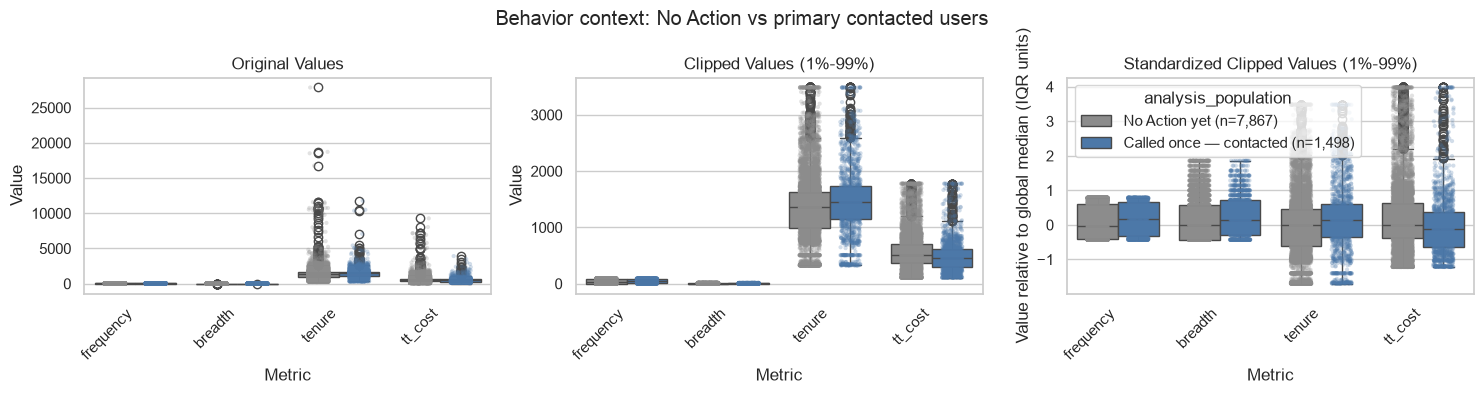

In [8]:
context_comparison = pd.concat(
    [
        df_no_action.assign(analysis_population="No Action yet"),
        df_analysis.assign(analysis_population="Called once — contacted"),
    ],
    ignore_index=True,
)
_ = plot_metric_boxplot_views(
    context_comparison,
    metrics=NUMERIC_FIELDS,
    group_col="analysis_population",
    group_order=["No Action yet", "Called once — contacted"],
    chart_title="Behavior context: No Action vs primary contacted users",
    chart_folder=OVERVIEW_CHART_DIR,
    file_name="no_action_vs_primary_contacted.png",
    show=True,
)

<span style="background-color: yellow; color:red">33 likely gammers are excluded in this comparison and covered in next section. This chart compares No Action users vs Normal contacted users.</span>

## 3. Repeated-call diagnostic

The business hypothesis is that repeatedly called users differ by nature. This comparison describes that difference, but repeat calling is post-contact behavior and its group may be small. It is therefore not mixed into the baseline or any downstream Saved-versus-Stopped analysis.

,field,row_count,non_null_count,null_count,null_pct,zero_count,negative_count,min,max,mean,median,std,p01,p05,p10,p25,p50,p75,p90,p95,p99,iqr,lower_bound,upper_bound,outlier_count,outlier_pct,repeated_call_group
0,frequency,20,20,0,0.00,2,0,0.00,91.00,48.40,43.50,33.40,0.00,0.00,5.40,20.00,43.50,78.25,89.10,90.05,90.81,58.25,-67.38,165.62,0,0.00,Contacted both ways
1,breadth,20,20,0,0.00,2,0,0.00,11.00,5.95,6.00,3.41,0.00,0.00,1.80,4.00,6.00,9.00,10.10,11.00,11.00,5.00,-3.50,16.50,0,0.00,Contacted both ways
2,tenure,20,20,0,0.00,0,0,340.00,"9,496.00","1,943.35","1,453.50","1,870.94",446.78,873.90,956.00,"1,235.00","1,453.50","2,005.75","2,514.70","3,331.45","8,263.09",770.75,78.88,"3,161.88",1,5.00,Contacted both ways
3,tt_cost,20,20,0,0.00,0,0,113.22,"1,579.50",555.57,555.85,340.80,120.21,148.19,219.79,306.83,555.85,679.07,916.92,"1,030.24","1,469.65",372.24,-251.52,"1,237.42",1,5.00,Contacted both ways
4,frequency,1498,1496,2,0.13,181,0,0.00,91.00,45.65,45.00,34.55,0.00,0.00,0.00,9.00,45.00,82.00,90.00,91.00,91.00,73.00,-100.50,191.50,0,0.00,Other
5,breadth,1498,1496,2,0.13,290,0,0.00,20.00,5.02,4.00,4.20,0.00,0.00,0.00,1.00,4.00,8.00,11.00,13.00,16.00,7.00,-9.50,18.50,1,0.07,Other
6,tenure,1498,1496,2,0.13,0,0,323.00,"11,789.00","1,495.04","1,450.00",796.53,325.00,358.75,675.00,"1,144.00","1,450.00","1,727.00","2,321.00","2,636.25","3,625.60",583.00,269.50,"2,601.50",85,5.68,Other
7,tt_cost,1498,1496,2,0.13,0,0,25.91,"3,925.74",504.48,462.87,337.23,108.23,119.76,169.16,289.96,462.87,620.59,825.10,999.88,"1,808.05",330.63,-205.98,"1,116.53",59,3.94,Other
8,frequency,13,12,1,7.69,0,0,27.00,91.00,73.00,89.00,22.97,28.98,36.90,45.70,53.50,89.00,90.25,91.00,91.00,91.00,36.75,-1.62,145.38,0,0.00,Pay less than start rate
9,breadth,13,12,1,7.69,0,0,2.00,14.00,6.00,5.00,3.49,2.11,2.55,3.00,3.75,5.00,7.50,9.90,11.80,13.56,3.75,-1.88,13.12,1,8.33,Pay less than start rate


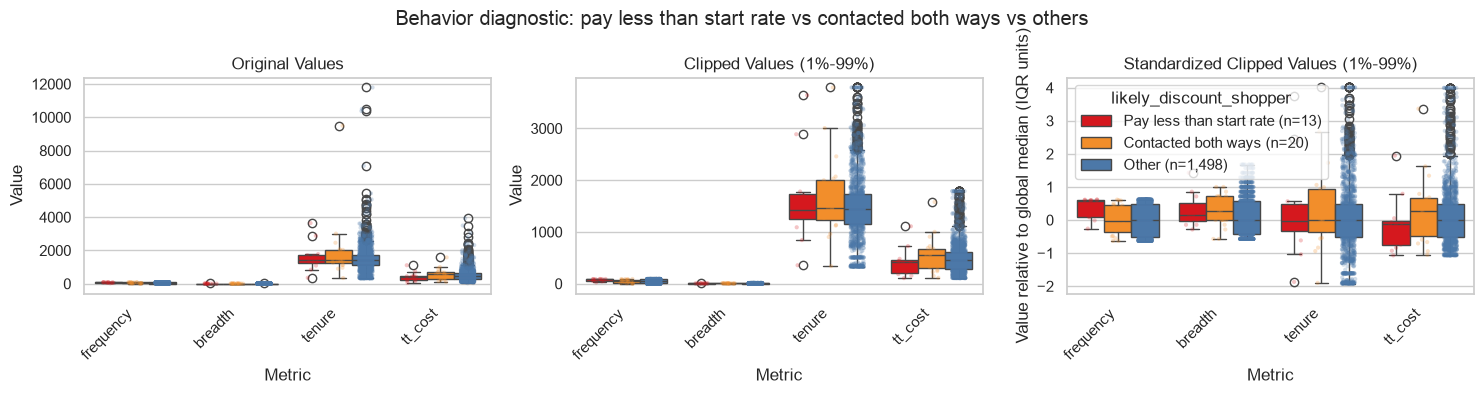

In [9]:
repeated_call_summary = pd.concat(
    [
        build_distribution_summary(group, NUMERIC_FIELDS).assign(
            repeated_call_group=group_name
        )
        for group_name, group in df_contacted.groupby(
            "likely_discount_shopper", observed=True
        )
    ],
    ignore_index=True,
)
repeated_call_summary.to_csv(
    TABLE_DIR / "likely_discount_shopper_behavior_summary.csv", index=False
)
display(repeated_call_summary)
_ = plot_metric_boxplot_views(
    df_contacted,
    metrics=NUMERIC_FIELDS,
    group_col="likely_discount_shopper",
    group_order=["Pay less than start rate", "Contacted both ways", "Other"],
    chart_title="Behavior diagnostic: pay less than start rate vs contacted both ways vs others",
    chart_folder=DIAGNOSTIC_CHART_DIR,
    file_name="pay_less_vs_contacted_both_vs_other.png",
    show=True,
)

<span style="background-color: yellow; color:red">Breakdown 33 likely gammers: pay less than start rate users have highest frequency and lowest total cost.</span>

## 4. Primary called-once Saved-versus-Stopped baseline

All remaining calculations use `df_analysis`. <span style="background-color: yellow; color:red">The common reference is fitted once on entire called-once contacted population</span>: clip each metric at its population 1st and 99th percentiles, subtract its population median, then divide by its population IQR.

In [10]:
behavior_reference = fit_behavior_reference(df_analysis, NUMERIC_FIELDS)
reference_table = pd.DataFrame(
    {
        "p01": behavior_reference["lower_bounds"],
        "median": behavior_reference["centers"],
        "iqr": behavior_reference["spreads"],
        "p99": behavior_reference["upper_bounds"],
    }
).rename_axis("metric").reset_index()
reference_table.to_csv(TABLE_DIR / "primary_behavior_reference.csv", index=False)
print("Contacted population behavior reference")
reference_table

Contacted population behavior reference


,metric,p01,median,iqr,p99
0,frequency,0.00,45.00,73.00,91.00
1,breadth,0.00,4.00,7.00,16.00
2,tenure,325.00,"1,450.00",583.00,"3,625.60"
3,tt_cost,108.23,462.87,330.63,"1,808.05"


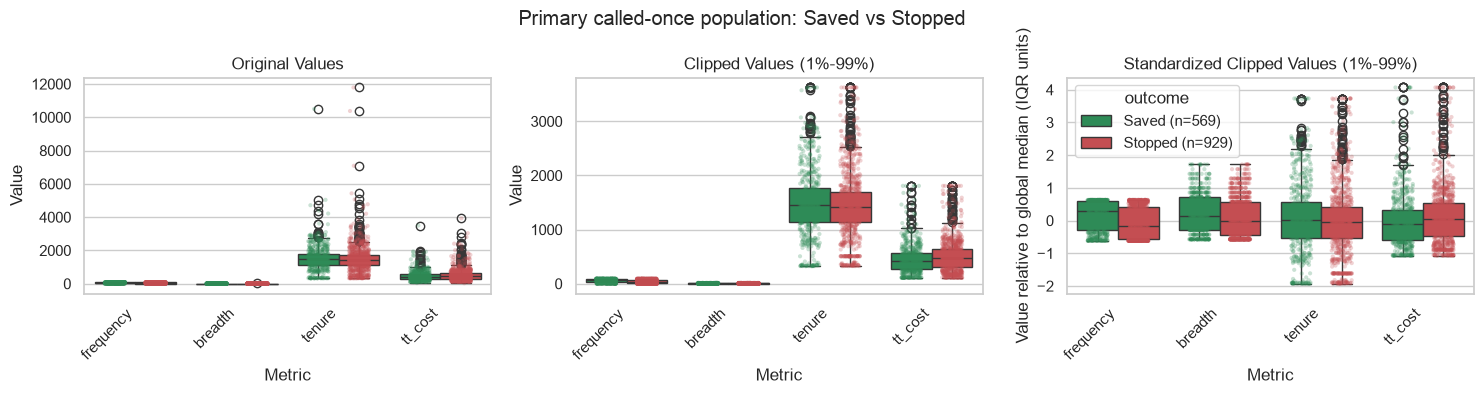

In [11]:
_ = plot_metric_boxplot_views(
    df_analysis,
    metrics=NUMERIC_FIELDS,
    group_col=OUTCOME_COL,
    group_order=list(OUTCOMES),
    chart_title="Primary called-once population: Saved vs Stopped",
    chart_folder=OVERVIEW_CHART_DIR,
    file_name="primary_saved_vs_stopped.png",
    show=True,
)

<span style="background-color: yellow; color:red">Compare saved vs stopped normal contacted users(exclude gammers): saved users have higher frequency/ breadth/ tenure and lower total cost.</span>

## 5. Absolute behavior profiles
Normalize features in the contact-channel, contact-timing, cohort, and risk-tier <span style="color:red">**slice**</span> with the <span style="color:red">**population reference**</span>, put features on a comparable scale. 

<span style="background-color: yellow; color:red">Interpretation:</span>
- Row labels:
    - *Outcome*: Stopped/ Saved 
    - *Segment label* (Contact Channel/Contact Timing/Cohort/Risk Tier); 
    - `n` indicates number of users in the segment.
- Scores for features median:
    - $ProfileScore_{s,m}=\frac{Median_{s,m} - Median_{all\ contacted,m}}{IQR_{all\ contacted,m}}$
    - *s*: segments. *m*: features.
    - IQR scaling is robust to skewed distributions and extreme values.
    - 0: same as the typical contacted account.
    - +1: one contacted-population IQR above typical.
    - -1: one IQR below typical.
- Adequate sample size for behavior profile: `20`

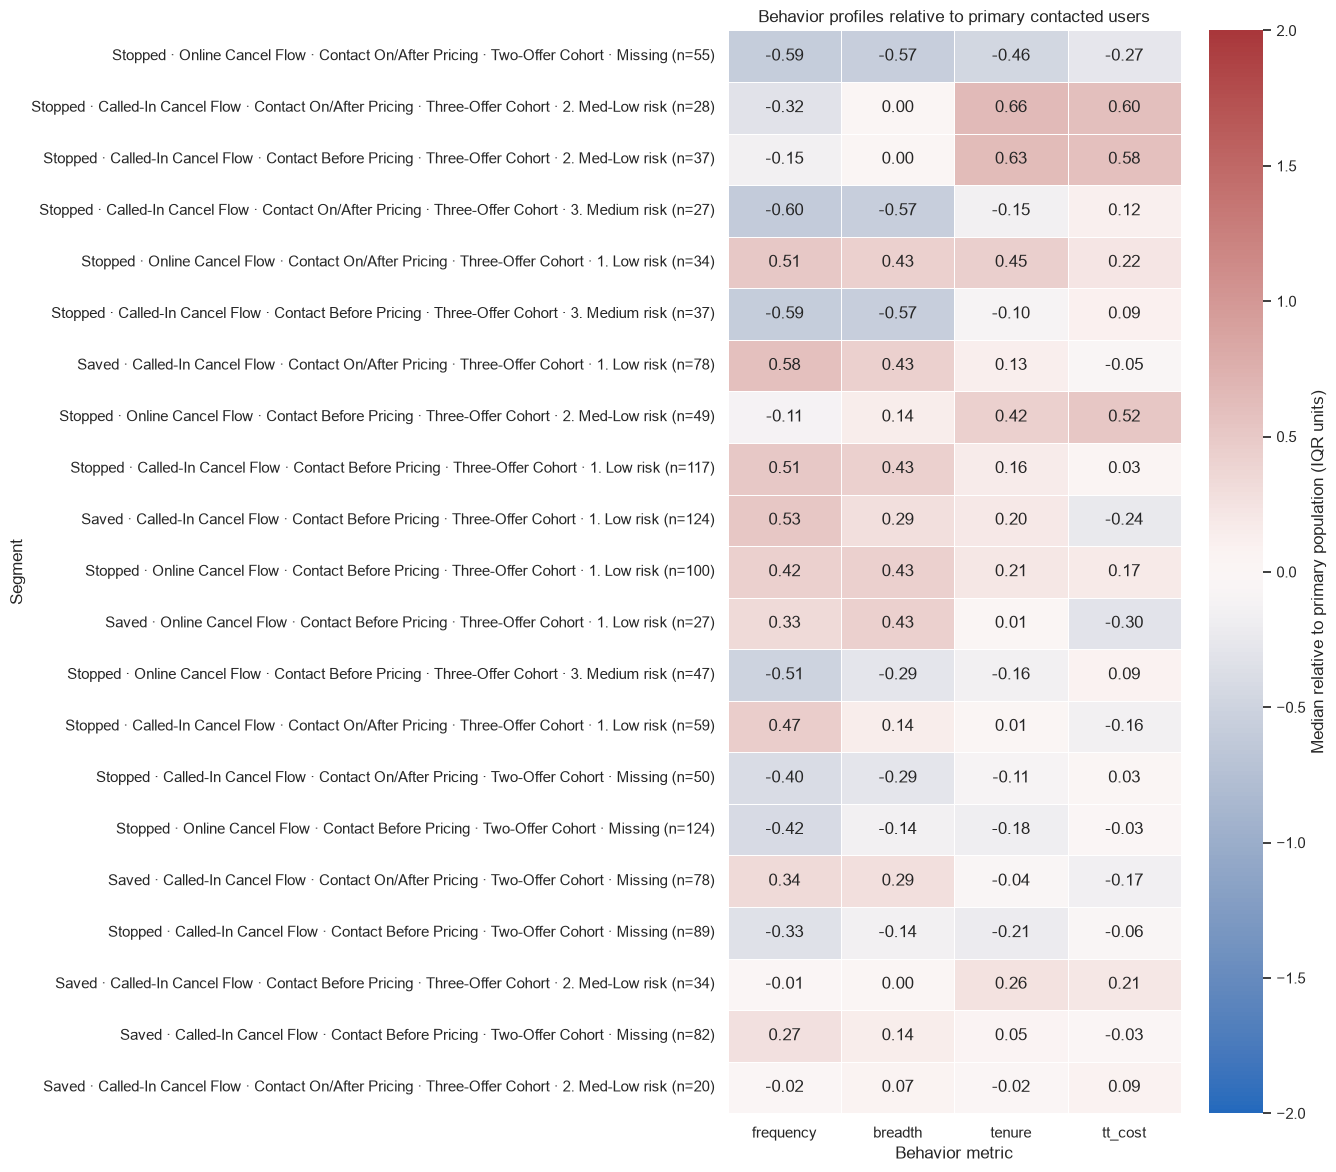

In [12]:
behavior_profiles = build_behavior_profiles(
    df_analysis,
    metrics=NUMERIC_FIELDS,
    segment_fields=PROFILE_FIELDS,
    reference=behavior_reference,
    min_n=MIN_PROFILE_USERS,
)
behavior_profiles.to_csv(TABLE_DIR / "behavior_profiles.csv", index=False)
# display(behavior_profiles.head(10))
_ = plot_profile_or_contrast_heatmap(
    behavior_profiles,
    metrics=NUMERIC_FIELDS,
    score_type="profile",
    max_rows=30,
    chart_folder=PROFILE_CHART_DIR,
    file_name="behavior_profiles.png",
    show=True,
)

In [13]:
print("Full combination of 40 slices:")
pd.DataFrame(df_analysis.groupby(
    PROFILE_FIELDS,
    dropna=False,
    observed=True,
    sort=False,
))[:10][0]

Full combination of 40 slices:


0    (Stopped, Called-In Cancel Flow, Contact Befor...
1    (Saved, Called-In Cancel Flow, Contact On/Afte...
2    (Saved, Called-In Cancel Flow, Contact On/Afte...
3    (Stopped, Online Cancel Flow, Contact Before P...
4    (Stopped, Called-In Cancel Flow, Contact On/Af...
5    (Stopped, Called-In Cancel Flow, Contact Befor...
6    (Stopped, Online Cancel Flow, Contact Before P...
7    (Saved, Called-In Cancel Flow, Contact Before ...
8    (Saved, Online Cancel Flow, Contact Before Pri...
9    (Saved, Called-In Cancel Flow, Contact Before ...
Name: 0, dtype: object

## 6. Matched Saved-minus-Stopped contrasts

Compares <span style="color:red">Saved-minus-Stopped</span> inside the same slice. 

<span style="background-color: yellow; color:red">Interpretation:</span>
- Row labels:
    - *Rank number*
    - *Segment label* (Contact Channel/Contact Timing/Cohort/Risk Tier)
    - `n` indicate number of saved users / number of stopped users in the segment.
- Save-minus-Stop Delta:
    - $OutcomeDelta_{s,m} = ProfileScore_{Saved,s,m} - ProfileScore_{Stopped,s,m}$
    - *s*: segments; *m*: features.
    - +: the Saved median is higher. 
    - -: the Stopped median is higher. 
- Segment Rank: multivariate behavioral contrast score across all four metrics (Euclidean magnitude):
    - $ContrastMagnitude_s = \sqrt{\sum_m OutcomeDelta_{s,m}^{2}}$
    - captures both "one exceptionally large metric difference" and "several moderately large differences"
    - Larger magnitude: the typical Saved and Stopped users have more distinct behavioral profiles.
- All contrast are calculated. Plot top `max_rows` contrast in the heatmap.

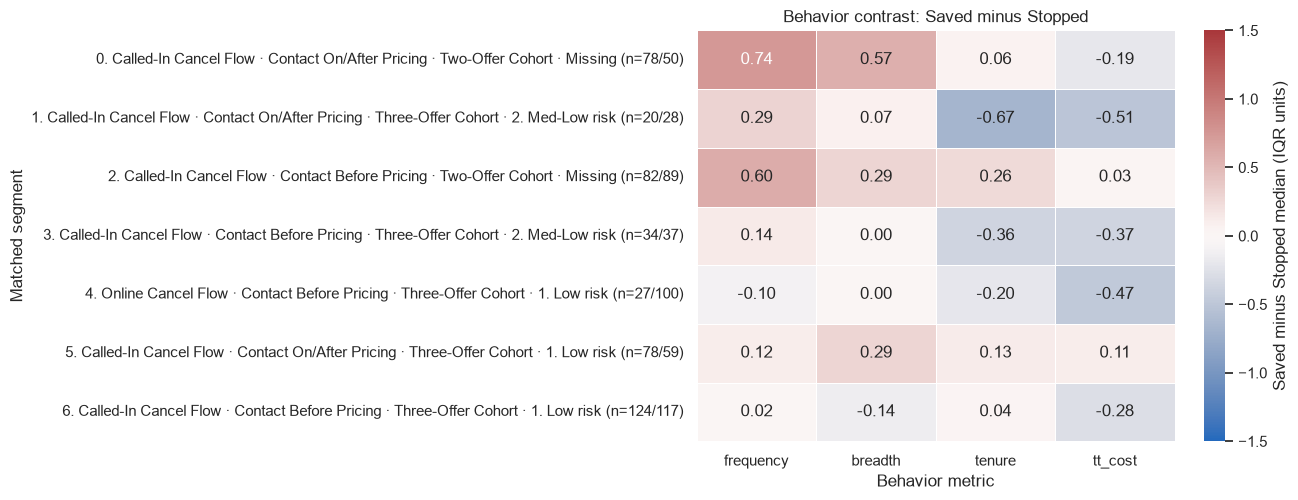

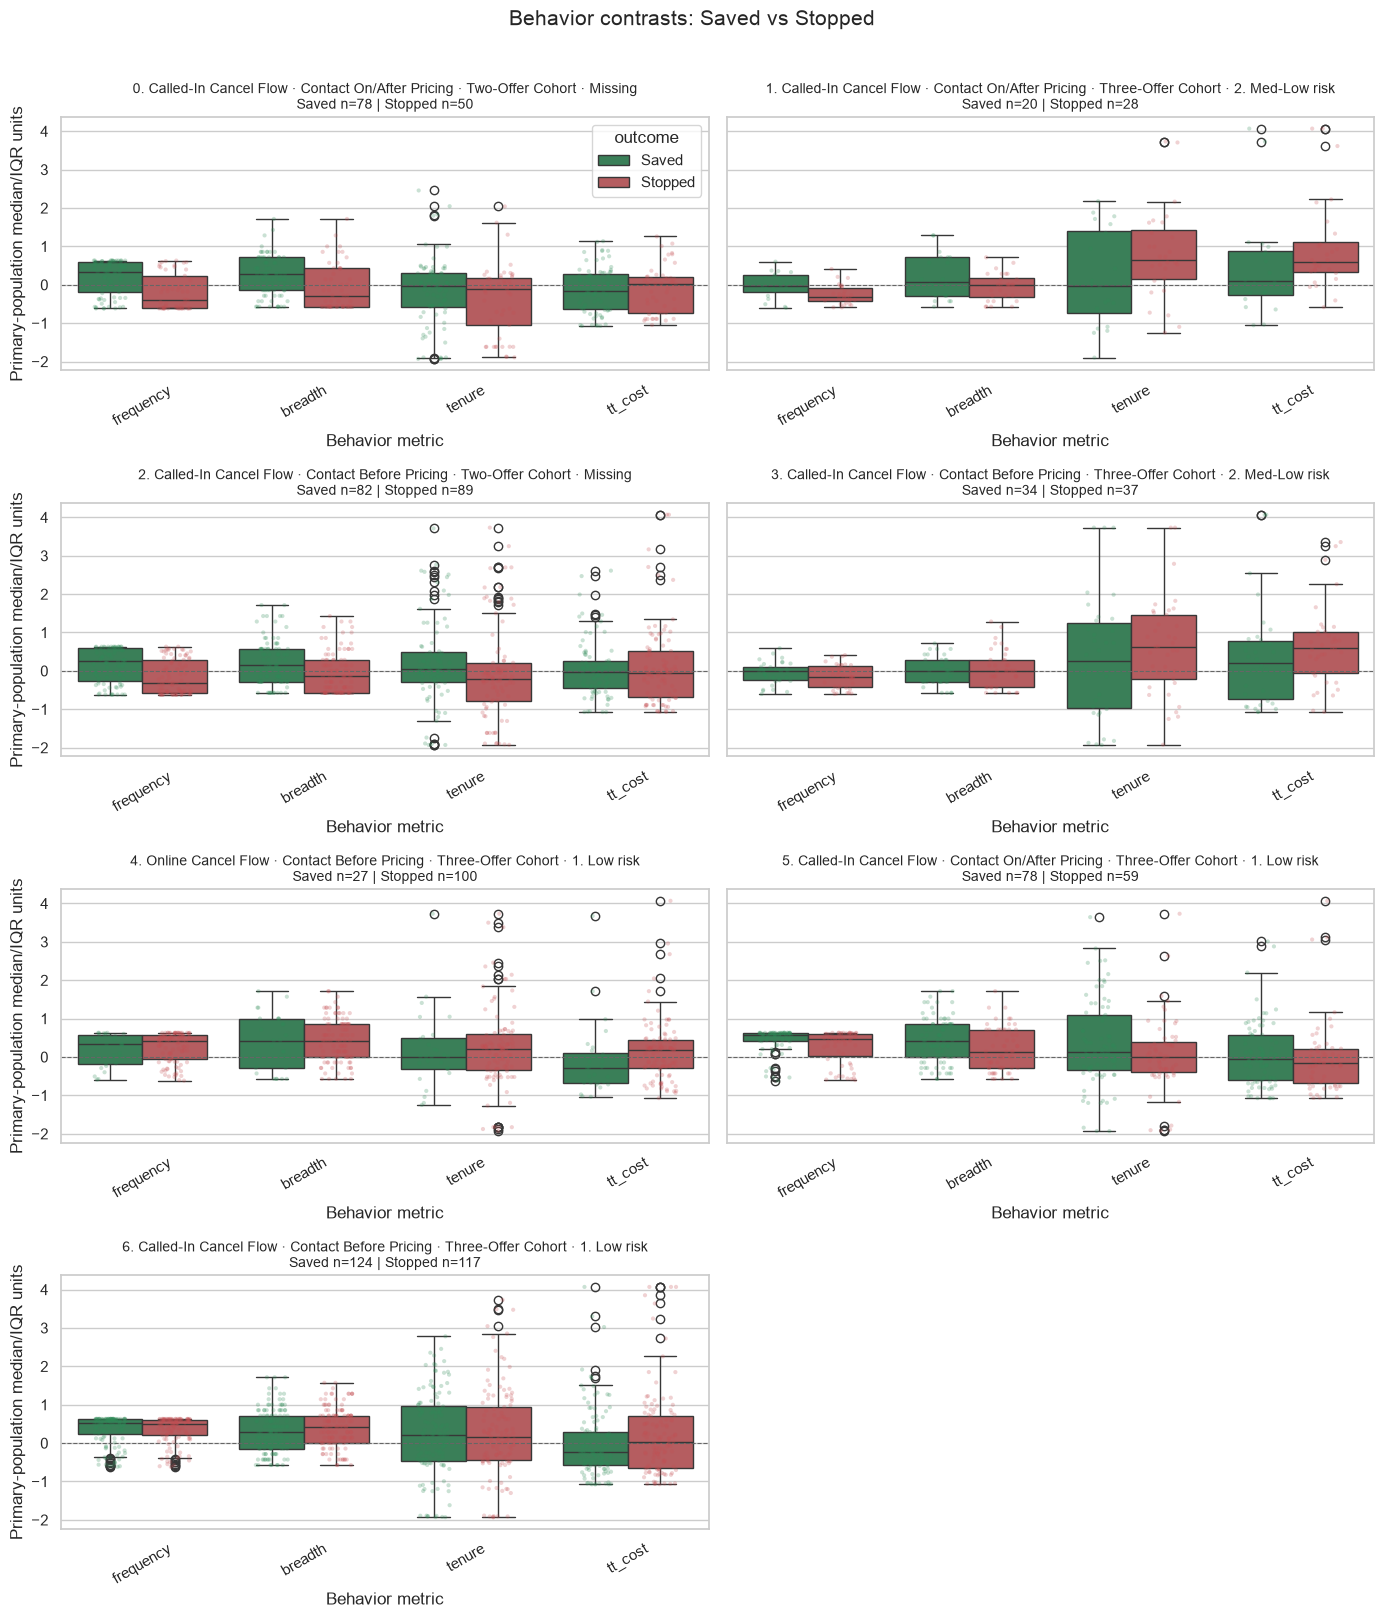

In [14]:
outcome_contrasts = build_outcome_contrasts(
    behavior_profiles,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS,
)
outcome_contrasts.to_csv(TABLE_DIR / "saved_minus_stopped_contrasts.csv", index=False)
# display(outcome_contrasts.head(TOP_CONTRASTS))
_ = plot_profile_or_contrast_heatmap(
    outcome_contrasts,
    metrics=NUMERIC_FIELDS,
    score_type="contrast",
    max_rows=20,
    color_limit=1.5,
    chart_folder=CONTRAST_CHART_DIR,
    title="Behavior contrast: Saved minus Stopped",
    file_name="saved_minus_stopped_contrasts.png",
    show=True,
)
_ = plot_behavior_contrasts_boxplots(
    df_analysis,
    outcome_contrasts,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS,
    reference=behavior_reference,
    top_n=TOP_CONTRASTS,
    chart_folder=CONTRAST_CHART_DIR,
    title="Behavior contrasts: Saved vs Stopped",
    file_name="top_behavior_contrasts.png",
    show=True,
)

## 7. Treatment drill-down within the selected segments
- The ranked segment list remain fixed from **Section 6** above. 
- Adequate sample size for Treatment behavior profile: both Saved and Stopped users meet `MIN_TREATMENT_USERS`=5
- Unsupported rows remain in the exported table with counts and blank standardized differences. 

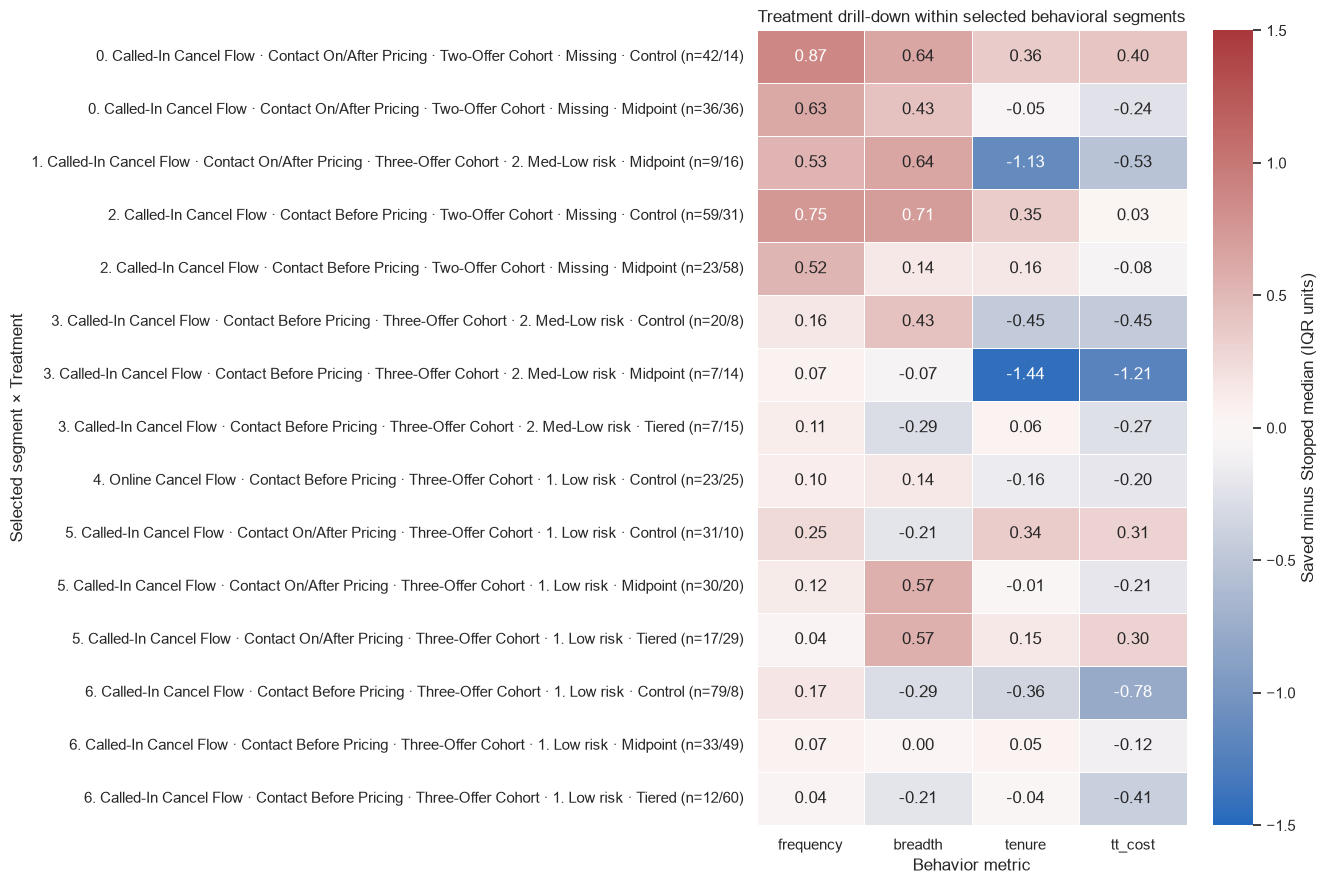

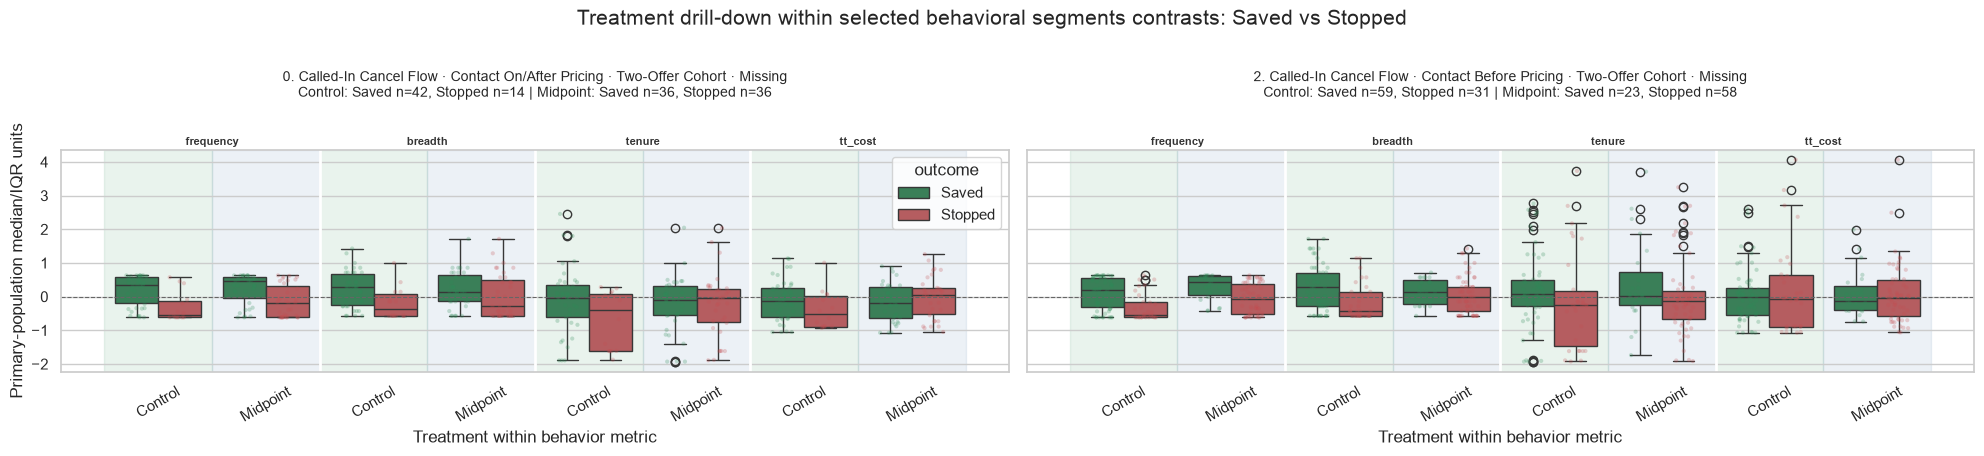

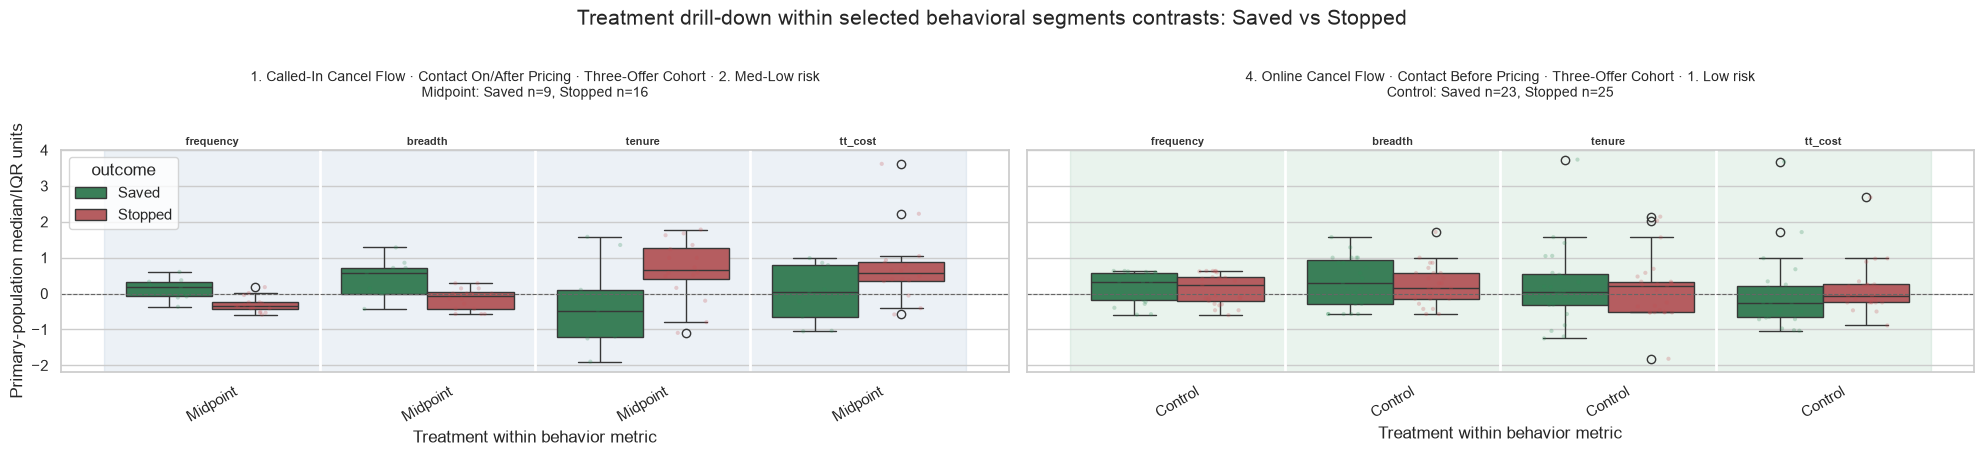

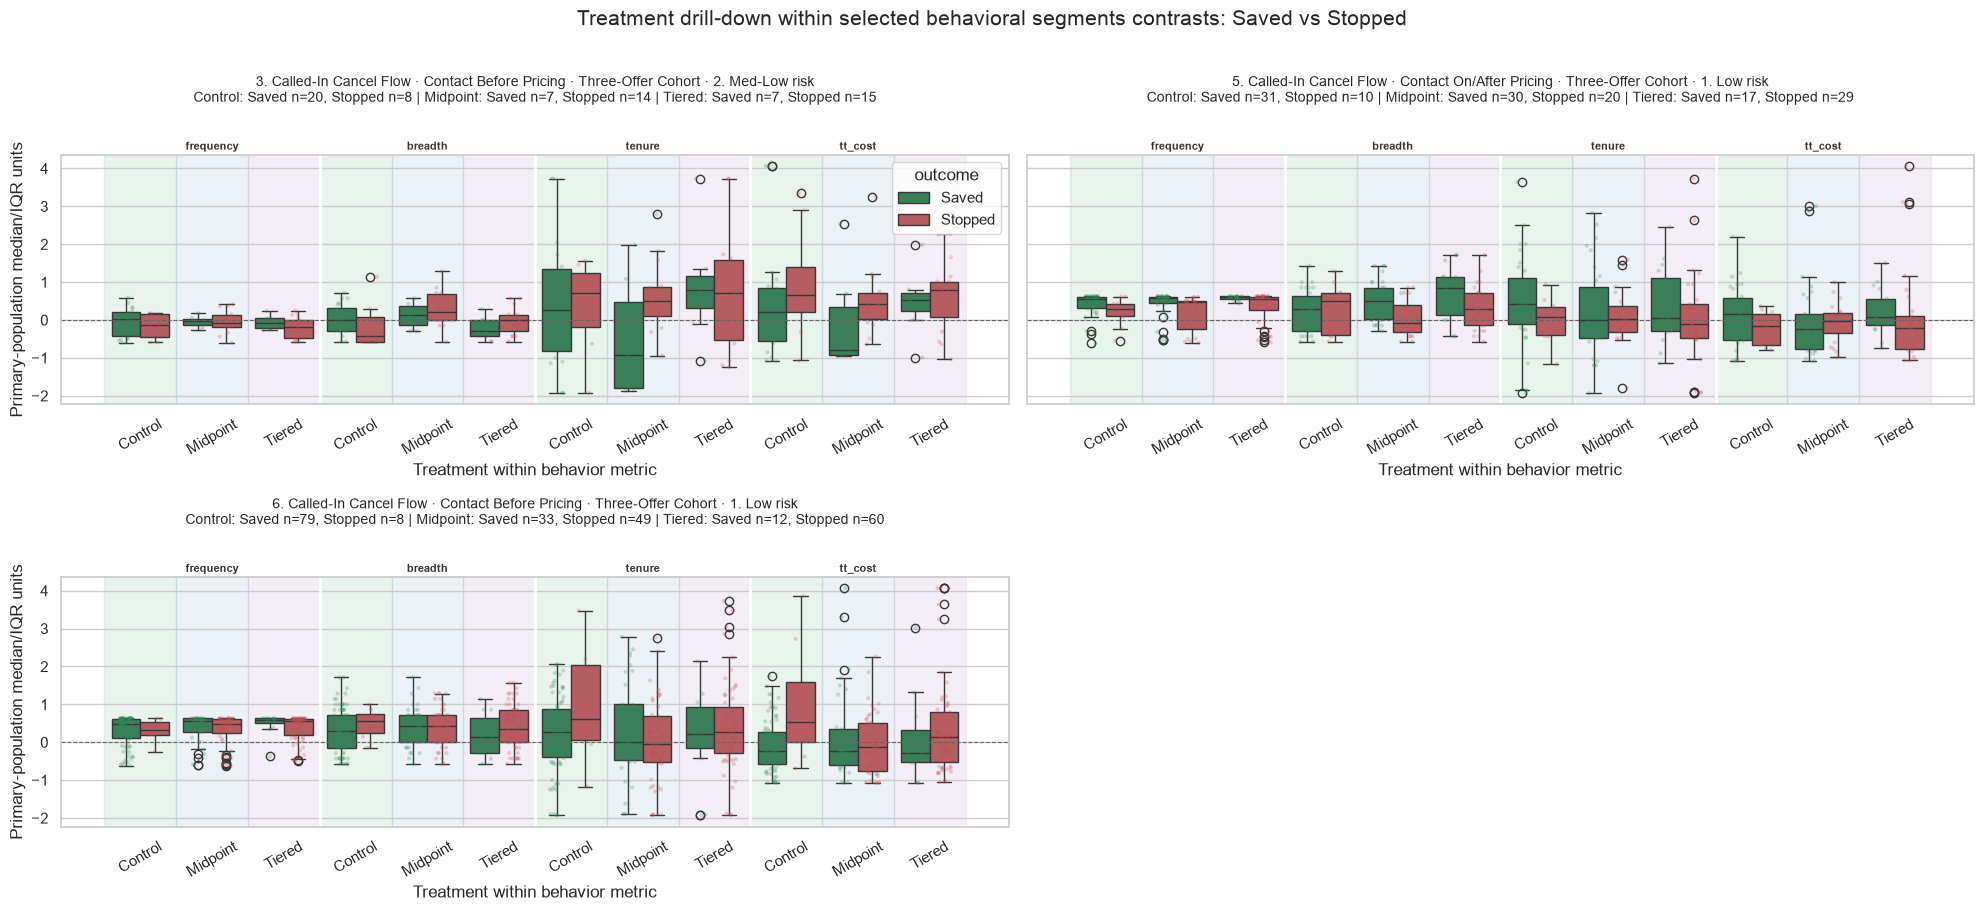

In [15]:
treatment_contrasts = build_treatment_contrasts(
    df_analysis,
    outcome_contrasts,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS,
    reference=behavior_reference,
    top_n=TOP_CONTRASTS,
    min_n=MIN_TREATMENT_USERS,
)
treatment_contrasts.to_csv(TABLE_DIR / "selected_segment_treatment_contrasts.csv", index=False)
# display(treatment_contrasts.head(5))
_ = plot_profile_or_contrast_heatmap(
    treatment_contrasts[treatment_contrasts["supported"]].copy(),
    metrics=NUMERIC_FIELDS,
    score_type="contrast",
    color_limit=1.5,
    title="Treatment drill-down within selected behavioral segments",
    chart_folder=CONTRAST_CHART_DIR,
    file_name="selected_segment_treatment_contrasts.png",
    show=True,
)
support = treatment_contrasts[treatment_contrasts["supported"]].copy()

for idx, rank in enumerate([[0,2], [1,4], [3,5,6]]):
    _ = plot_behavior_contrasts_boxplots(
        df_analysis,
        support[support["segment_rank"].isin(rank)].copy(),
        metrics=NUMERIC_FIELDS,
        segment_fields=BASE_SEGMENT_FIELDS + ["Treatment"],
        reference=behavior_reference,
        top_n=TOP_CONTRASTS,
        panel_size=(10, 4.5),
        treatment_layout="metric_first",
        chart_folder=CONTRAST_CHART_DIR,
        title="Treatment drill-down within selected behavioral segments contrasts: Saved vs Stopped",
        file_name=f"top_behavior_treatment_contrasts_{idx}.png",
        show=True,
    )

## 8. Business magnitude and uncertainty for selected segments drilled-down to Treatment

Only the fixed top pooled-treatment segments are expanded. Raw clipped boxplots retain business units; the detail table reuses the selected contrast counts and adds clipped medians, IQRs, and optional bootstrap intervals for median differences. Full-value grids are intentionally omitted.

,segment_rank,segment_label,contact_channel_group,contact_timing,cohort,src_risk_tier,Treatment,metric,n__saved,non_null__saved,clipped_median__saved,clipped_q25__saved,clipped_q75__saved,clipped_iqr__saved,n__stopped,non_null__stopped,clipped_median__stopped,clipped_q25__stopped,clipped_q75__stopped,clipped_iqr__stopped,clipped_median_difference,clipped_median_difference_ci_lower,clipped_median_difference_ci_upper,bootstrap_iterations,confidence_level
0,0,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Control,frequency,42,42,69.50,30.50,87.75,57.25,14,14,6.00,0.00,36.25,36.25,63.50,26.99,79.51,2000,0.95
1,0,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Control,breadth,42,42,6.00,2.25,8.75,6.50,14,14,1.50,0.00,4.50,4.50,4.50,1.00,6.50,2000,0.95
2,0,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Control,tenure,42,42,"1,434.50","1,101.50","1,653.50",552.00,14,14,"1,224.00",507.50,"1,500.25",992.75,210.50,-142.17,973.00,2000,0.95
3,0,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Control,tt_cost,42,42,420.25,258.54,543.51,284.97,14,14,287.37,169.00,469.60,300.61,132.88,-62.12,307.45,2000,0.95
4,0,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Midpoint,frequency,36,35,78.00,43.00,87.50,44.50,36,35,32.00,0.00,68.00,68.00,46.00,25.00,76.00,2000,0.95


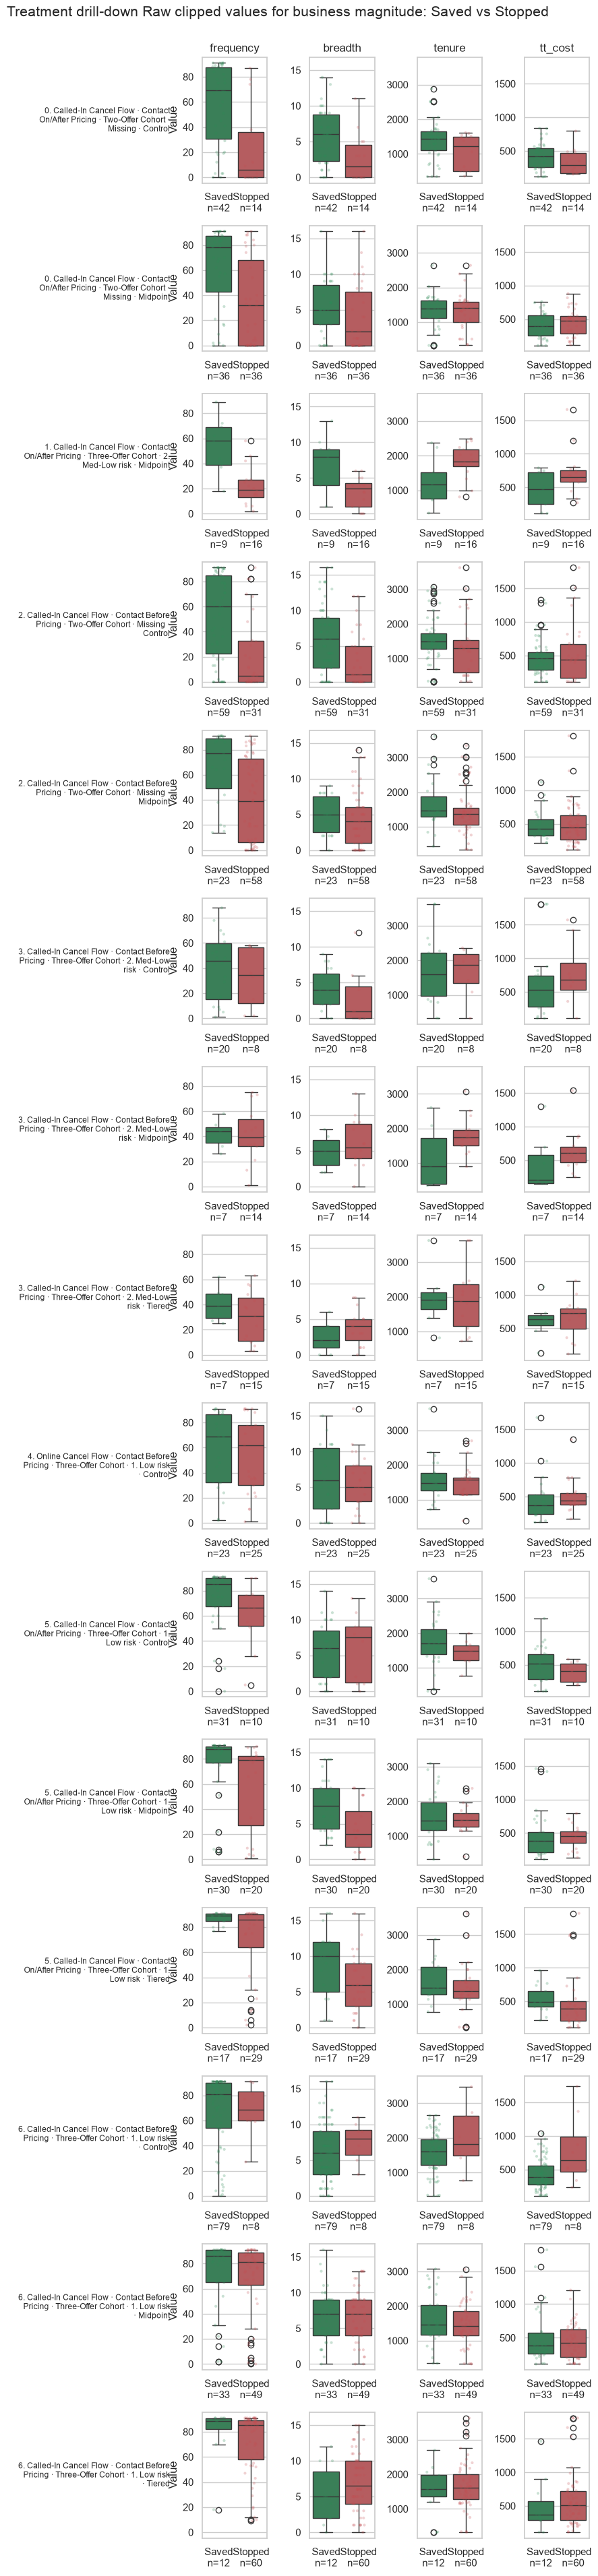

In [16]:
selected_segment_treatment_details = build_selected_segment_detail_table(
    df_analysis,
    treatment_contrasts,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS+['Treatment'],
    reference=behavior_reference,
    top_n=30,
    bootstrap_iterations=BOOTSTRAP_ITERATIONS,
    confidence_level=BOOTSTRAP_CONFIDENCE_LEVEL,
)
selected_segment_treatment_details.to_csv(TABLE_DIR / "selected_segment_details.csv", index=False)
display(selected_segment_treatment_details.head(5))
_ = plot_selected_segment_clipped_boxplot_grid(
    df_analysis,
    treatment_contrasts[treatment_contrasts["supported"]].copy(),
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS+['Treatment'],
    reference=behavior_reference,
    top_n=30,
    chart_folder=CONTRAST_CHART_DIR,
    title="Treatment drill-down Raw clipped values for business magnitude: Saved vs Stopped",
    file_name="treatment_selected_segments_raw_clipped.png",
    show=True,
)

## 9. Key findings and business insights

These findings describe the current mature-subscriber extract and characterize associations within the contacted population. They do not estimate treatment effects, and observed Saved share is not a substitute for CNRC.

### Population context

- Of 9,398 mature notified accounts, 1,531 (16.3%) contacted. The analysis therefore describes callers/cancel-flow users, not the much larger population that did not contact.
- The 33 likely discount shoppers or users who contacted through both channels have a distinct behavioral pattern and remain a separate operational diagnostic. In particular, the pay-less-than-start-rate group has very high frequency and comparatively low `tt_cost`; mixing these users into the baseline would distort the Saved-versus-Stopped profile.
- After that exclusion, the primary population contains 1,498 accounts: 569 Saved and 929 Stopped, an observed Saved share of 38.0%. This is useful context for profiling but is not a treatment-performance estimate.

### Overall Saved-versus-Stopped profile

- Saved users are primarily distinguished by engagement intensity: median frequency is 65.5 versus 33.0 for Stopped users, while median breadth is 5 versus 4.
- Median tenure is nearly the same overall (1,454 versus 1,421), and Saved users have lower median `tt_cost` (428 versus 484). The overall Saved profile is therefore **more engaged**, not simply older or higher on every value measure.
- The broad distributions still overlap. These features are more useful for identifying behavioral profiles and investigation targets than for treating every high-frequency account as inherently saveable.

### Where the outcome contrast is concentrated

- **Two-Offer, call-in users show the clearest engagement pattern.** For contacts on/after pricing, Saved users have median frequency/breadth of 70/6 versus 16/2 for Stopped users. For contacts before pricing, the corresponding medians are 64.5/5 versus 21/3. Frequency remains higher for Saved users under both supported Control and Midpoint cells, so the pooled pattern is not being produced by only one available treatment.
- **Three-Offer, Med-Low-risk call-in users show a different profile.** Saved users are somewhat more frequent but have materially shorter tenure and lower `tt_cost` than Stopped users, both before and on/after pricing. There is no single universal Saved-user persona: in this slice, being more established or higher-cost does not correspond to the observed Saved outcome.
- **Online, before-pricing, Low-risk users are the clearest retention-risk journey in the matched results.** This slice has the lowest observed Saved share (27 Saved versus 100 Stopped, or 21.3%). Saved users also have lower frequency, tenure, and `tt_cost`; the Stopped users in this journey are comparatively established and higher-cost, making the online pre-pricing experience a useful target for journey and friction research.
- **The large Low-risk call-in slices are less behaviorally separable.** Their observed Saved shares are roughly balanced, and their standardized contrasts are smaller. Behavior history alone is unlikely to explain outcomes in these high-volume slices.

### Treatment drill-down and uncertainty

- Fifteen of the 21 selected segment-treatment cells meet the minimum support rule. Some segments have only one supported treatment, so they cannot support across-treatment behavioral comparisons.
- Only 10 of the 60 supported treatment-by-metric median differences have 95% bootstrap intervals that exclude zero; nine of those are frequency or breadth. No supported `tt_cost` difference excludes zero. The most repeatable treatment-level evidence is therefore engagement-related, while apparent tenure and cost differences require more caution.
- The Two-Offer call-in frequency gaps are the strongest repeated examples: on/after pricing, Saved-minus-Stopped medians are +63.5 under Control and +46 under Midpoint; before pricing, they are +55 and +38. All four frequency intervals exclude zero.

### Business implications

1. Use frequency and breadth as behavioral context for retention monitoring and for forming pre-specified interaction hypotheses, especially in the Two-Offer call-in journeys.
2. Prioritize the Online / Before Pricing / Low-risk journey for process research: its low observed Saved share and the profile of its Stopped users suggest a concentrated retention-risk opportunity.
3. Keep likely discount shoppers and both-channel contacts in a separate operational lens; they should not define the standard contacted-user profile.
4. Do not select a treatment from these boxplots. Reconcile any behavioral hypothesis with the randomized treatment results and make the business decision on CNRC, which incorporates both retention and realized revenue.

## 10. Interpretation guide

Use the repeated-call section to describe who tends to contact repeatedly, not to explain Saved-versus-Stopped differences. Use absolute profiles to characterize where a slice sits relative to all called-once contacts, and matched contrasts to state how Saved users differ from Stopped users inside the same slice. Confirm a ranked standardized contrast in the raw clipped chart before translating it into business magnitude.

Bootstrap intervals describe uncertainty in the observed median difference; they do not establish causality. Treatment-level patterns are hypotheses to reconcile with the completed randomized treatment/CNRC evaluation, especially when support is near the minimum.